In [11]:
import pandas as pd
import os
from sklearn.svm import SVR
from glob import glob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt
from features import features
from imblearn.over_sampling import SMOTE
from collections import Counter


import sys
from pathlib import Path

# 导入公共路径
sys.path.append(str(Path("../00_common").resolve()))
from base_path import ROOT

# 输出路径：02 Stacking/t+3/
path = ROOT / "02 Stacking" / "补充实验"

# 输入路径：上一步分用户的 CSV
input_folder = ROOT / "01 数据处理" / "07split_by_uid"

# 如果输出目录不存在，就创建
path.mkdir(parents=True, exist_ok=True)

print("输入文件夹：", input_folder)
print("输出路径：", path)




# 挑选出3天pam的值
output_hysteresis = path / "滞后特征"
output_abnormal = path / "异常值编码"
merged_file_path = path / "final.csv"
filtered_file_path = path / "final0.7.csv"
# 主循环中传递滞后窗口大小
lag_window = 7  # 可以灵活调整滞后窗口大小
predict_horizon = 3  # 预测几天后的 pam 变化，例如2表示 t+2

输入文件夹： /home/wei/Data/light/01 数据处理/07split_by_uid
输出路径： /home/wei/Data/light/02 Stacking/补充实验


# 1. 创建滞后特征 ==========

In [12]:
features = features  # 假设有这些特征

input_files = glob(os.path.join(input_folder, "*.csv"))
all_data = []

os.makedirs(output_hysteresis, exist_ok=True)

# 定义滞后特征提取函数
def extract_lagged_features(df, required_columns, lag_window, predict_horizon):
    rows = []

    # 确保按 day 排序
    df = df.sort_values("day").reset_index(drop=True)

    for i in range(lag_window, len(df)):
        pam_t = df.loc[i, "pam"]

        if i + predict_horizon >= len(df):
            break

        pam_t_future = df.loc[i + predict_horizon, "pam"]

        if pd.isna(pam_t) or pd.isna(pam_t_future):
            continue

        day_t = df.loc[i, "day"]
        day_future = df.loc[i + predict_horizon, "day"]

        # 提取 t-lag_window 到 t 的特征
        lagged_features = [
            df.loc[i - j, required_columns]
            for j in range(lag_window, -1, -1)
        ]

        rolling_window = pd.DataFrame(lagged_features)

        # 计算统计特征
        rolling_mean = rolling_window.mean()
        rolling_std = rolling_window.std()
        rolling_skew = rolling_window.skew()

        # 构造特征行
        row = (
            [day_t, day_future]
            + list(rolling_window.values.flatten())
            + rolling_mean.tolist()
            + rolling_std.tolist()
            + rolling_skew.tolist()
            + [pam_t_future - pam_t]
        )

        rows.append(row)

    return rows

# 主循环处理所有输入文件
for file in input_files:
    df = pd.read_csv(file)

    # day 只用于排序和记录 day_t / day_future，不作为模型特征
    required_columns = [
        col for col in features
        if col in df.columns and col not in ["day", "date"]
    ]

    rows = extract_lagged_features(df, required_columns, lag_window, predict_horizon)

    if rows:
        # 构建列名
        columns = (
            ["day_t", "day_future"]
            + [f"{col}_t-{i}" for i in range(lag_window, -1, -1) for col in required_columns]
            + [f"{col}_mean" for col in required_columns]
            + [f"{col}_std" for col in required_columns]
            + [f"{col}_skew" for col in required_columns]
            + ["target"]
        )

        output_df = pd.DataFrame(rows, columns=columns)
        output_file = os.path.join(output_hysteresis, os.path.basename(file))
        output_df.to_csv(output_file, index=False)
        all_data.append(output_df)

# 2. 异常值编码 ==========

In [13]:
input_folder = output_hysteresis
os.makedirs(output_abnormal, exist_ok=True)

input_files = glob(os.path.join(input_folder, "*.csv"))

total_instances = 0
file_instance_info = []

for file in input_files:
    data = pd.read_csv(file)

    file_name = os.path.basename(file)
    original_num = len(data)

    if data.empty:
        print(f"跳过空文件：{file_name}，实例数：0")
        continue

    data.fillna(-1, inplace=True)
    encoded_columns = {}

    if "target" not in data.columns:
        print(f"跳过无 target 文件：{file_name}，实例数：{original_num}")
        continue

    isolation_forest = IsolationForest(contamination=0.05, random_state=42)
    # anomaly_scores = isolation_forest.fit_predict(data.drop(columns=["target"]))
    meta_cols = ["day_t", "day_future"]
    feature_data = data.drop(columns=["target"] + meta_cols, errors="ignore")

    anomaly_scores = isolation_forest.fit_predict(feature_data)
    data["anomaly"] = anomaly_scores

    for column in data.columns:
        if column in ["target", "day_t", "day_future"]:
            continue

        if pd.api.types.is_numeric_dtype(data[column]) and not pd.api.types.is_bool_dtype(data[column]):
            Q1 = data[column].quantile(0.25)
            Q3 = data[column].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            encoded_columns[f"{column}_encoded"] = data[column].apply(
                lambda x: 0 if x < lower_bound else (2 if x > upper_bound else 1)
            )

    encoded_data = pd.DataFrame(encoded_columns)
    final_data = pd.concat([data, encoded_data], axis=1)

    abnormal_file_path = os.path.join(output_abnormal, file_name)
    final_data.to_csv(abnormal_file_path, index=False)

    final_num = len(final_data)
    total_instances += final_num

    file_instance_info.append({
        "file": file_name,
        "instances": final_num
    })

    print(f"已生成异常编码文件：{abnormal_file_path}，实例数：{final_num}")

print("=" * 80)
print(f"共处理文件数：{len(file_instance_info)}")
print(f"总实例数：{total_instances}")

已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/1.csv，实例数：16
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/2.csv，实例数：27
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/5.csv，实例数：26
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/6.csv，实例数：46
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/8.csv，实例数：31
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/9.csv，实例数：78
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/11.csv，实例数：73
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/12.csv，实例数：63
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/13.csv，实例数：25
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/14.csv，实例数：23
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/15.csv，实例数：34
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/20.csv，实例数：24
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/21.csv，实例数：22
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/22.csv，实例数：11
已生成异常编码文件：/home/wei/Data/light/02 Stacking/补充实验/异常值编码/

# 3. 合成 Final 文件 ==========

In [14]:
import os
import pandas as pd
import numpy as np
from glob import glob

directory_path = output_abnormal

train_ratio = 0.7
val_ratio = 0.1
test_ratio = 0.2

random_state = 42
rng = np.random.default_rng(random_state)

# =========================
# 1. 读取每个参与者文件的信息
# =========================

participant_info = []

csv_files = [
    os.path.join(directory_path, file_name)
    for file_name in os.listdir(directory_path)
    if file_name.endswith(".csv")
]

if len(csv_files) == 0:
    raise ValueError(f"没有找到 CSV 文件：{directory_path}")

for file_path in csv_files:
    try:
        df = pd.read_csv(file_path)

        if df.empty:
            print(f"跳过空文件：{file_path}")
            continue

        participant_info.append({
            "file_path": file_path,
            "file_name": os.path.basename(file_path),
            "instances": len(df)
        })

    except pd.errors.EmptyDataError:
        print(f"跳过无内容文件：{file_path}")
        continue

participant_info = pd.DataFrame(participant_info)

if participant_info.empty:
    raise ValueError("没有可用于划分的参与者文件。")

total_participants = len(participant_info)
total_instances = participant_info["instances"].sum()

target_participants = {
    "train": total_participants * train_ratio,
    "val": total_participants * val_ratio,
    "test": total_participants * test_ratio
}

target_instances = {
    "train": total_instances * train_ratio,
    "val": total_instances * val_ratio,
    "test": total_instances * test_ratio
}

print("=" * 80)
print("总参与者数：", total_participants)
print("总实例数：", total_instances)
print("目标参与者数：", target_participants)
print("目标实例数：", target_instances)

# =========================
# 2. 按参与者划分，并尽量平衡实例数
# =========================

# 先随机打乱，再按实例数从大到小分配
participant_info = participant_info.sample(
    frac=1,
    random_state=random_state
).sort_values(
    by="instances",
    ascending=False
).reset_index(drop=True)

splits = {
    "train": {
        "rows": [],
        "participants": 0,
        "instances": 0
    },
    "val": {
        "rows": [],
        "participants": 0,
        "instances": 0
    },
    "test": {
        "rows": [],
        "participants": 0,
        "instances": 0
    }
}

# 权重：实例数更重要，参与者数量也要考虑
instance_weight = 0.7
participant_weight = 0.3

for _, row in participant_info.iterrows():
    best_split = None
    best_score = float("inf")

    for split_name in ["train", "val", "test"]:
        new_instances = splits[split_name]["instances"] + row["instances"]
        new_participants = splits[split_name]["participants"] + 1

        instance_score = abs(new_instances - target_instances[split_name]) / target_instances[split_name]
        participant_score = abs(new_participants - target_participants[split_name]) / target_participants[split_name]

        score = instance_weight * instance_score + participant_weight * participant_score

        if score < best_score:
            best_score = score
            best_split = split_name

    splits[best_split]["rows"].append(row)
    splits[best_split]["participants"] += 1
    splits[best_split]["instances"] += row["instances"]

# =========================
# 3. 合并每个 split 的 CSV
# =========================

def load_split_data(rows, split_name):
    dfs = []

    for row in rows:
        df = pd.read_csv(row["file_path"])

        if df.empty:
            continue

        df["source_file"] = row["file_name"]
        df["split"] = split_name

        dfs.append(df)

    if len(dfs) == 0:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)


train_df = load_split_data(splits["train"]["rows"], "train")
val_df = load_split_data(splits["val"]["rows"], "val")
test_df = load_split_data(splits["test"]["rows"], "test")

# =========================
# 4. 保存文件
# =========================

train_file_path = path / "train_grouped.csv"
val_file_path = path / "val_grouped.csv"
test_file_path = path / "test_grouped.csv"

train_df.to_csv(train_file_path, index=False)
val_df.to_csv(val_file_path, index=False)
test_df.to_csv(test_file_path, index=False)

# 保存参与者划分信息
split_records = []

for split_name in ["train", "val", "test"]:
    for row in splits[split_name]["rows"]:
        split_records.append({
            "file_name": row["file_name"],
            "split": split_name,
            "instances": row["instances"]
        })

split_info = pd.DataFrame(split_records)
split_info_file_path = path / "participant_grouped_split_info.csv"
split_info.to_csv(split_info_file_path, index=False)

# =========================
# 5. 打印统计信息
# =========================

print("=" * 80)
print("Participant-grouped split 完成")
print("=" * 80)

for split_name, df_split in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    info = split_info[split_info["split"] == split_name]

    n_participants = len(info)
    n_instances = len(df_split)

    print(f"{split_name}:")
    print(f"  参与者数：{n_participants}")
    print(f"  参与者比例：{n_participants / total_participants * 100:.2f}%")
    print(f"  实例数：{n_instances}")
    print(f"  实例比例：{n_instances / total_instances * 100:.2f}%")
    print(f"  文件：{path / (split_name + '_grouped.csv')}")

print("=" * 80)
print("参与者划分信息文件：", split_info_file_path)

# =========================
# 6. 检查参与者是否重叠
# =========================

train_files = set(split_info[split_info["split"] == "train"]["file_name"])
val_files = set(split_info[split_info["split"] == "val"]["file_name"])
test_files = set(split_info[split_info["split"] == "test"]["file_name"])

print("train ∩ val 参与者重叠数：", len(train_files & val_files))
print("train ∩ test 参与者重叠数：", len(train_files & test_files))
print("val ∩ test 参与者重叠数：", len(val_files & test_files))

总参与者数： 123
总实例数： 4295
目标参与者数： {'train': 86.1, 'val': 12.3, 'test': 24.6}
目标实例数： {'train': np.float64(3006.5), 'val': np.float64(429.5), 'test': np.float64(859.0)}
Participant-grouped split 完成
train:
  参与者数：81
  参与者比例：65.85%
  实例数：1273
  实例比例：29.64%
  文件：/home/wei/Data/light/02 Stacking/补充实验/train_grouped.csv
val:
  参与者数：13
  参与者比例：10.57%
  实例数：1019
  实例比例：23.73%
  文件：/home/wei/Data/light/02 Stacking/补充实验/val_grouped.csv
test:
  参与者数：29
  参与者比例：23.58%
  实例数：2003
  实例比例：46.64%
  文件：/home/wei/Data/light/02 Stacking/补充实验/test_grouped.csv
参与者划分信息文件： /home/wei/Data/light/02 Stacking/补充实验/participant_grouped_split_info.csv
train ∩ val 参与者重叠数： 0
train ∩ test 参与者重叠数： 0
val ∩ test 参与者重叠数： 0


# 4. 筛选缺失值 ==========

In [15]:
filtered_train_file_path = path / "train_chronological_0.7.csv"
filtered_val_file_path = path / "val_chronological_0.7.csv"
filtered_test_file_path = path / "test_chronological_0.7.csv"

train_data = pd.read_csv(train_file_path)
val_data = pd.read_csv(val_file_path)
test_data = pd.read_csv(test_file_path)

# 不要根据这些元信息列的缺失率决定是否保留
meta_cols = ["target", "day_t", "day_future", "source_file"]

# 只在训练集特征列上计算缺失率
feature_cols = [
    col for col in train_data.columns
    if col not in meta_cols
]

missing_percentage = train_data[feature_cols].isnull().mean() * 100

# 训练集中缺失率 <= 30% 的特征列
selected_feature_cols = missing_percentage[
    missing_percentage <= 30
].index.tolist()

# 最终保留列：元信息列 + 被选中的特征列
selected_columns = [
    col for col in meta_cols
    if col in train_data.columns
] + selected_feature_cols

# train / val / test 都使用训练集确定的同一批列
filtered_train_data = train_data[selected_columns]
filtered_val_data = val_data[selected_columns]
filtered_test_data = test_data[selected_columns]

filtered_train_data.to_csv(filtered_train_file_path, index=False)
filtered_val_data.to_csv(filtered_val_file_path, index=False)
filtered_test_data.to_csv(filtered_test_file_path, index=False)

print("训练集缺失筛选后形状：", filtered_train_data.shape)
print("验证集缺失筛选后形状：", filtered_val_data.shape)
print("测试集缺失筛选后形状：", filtered_test_data.shape)
print("保留特征数：", len(selected_feature_cols))

print("训练集文件：", filtered_train_file_path)
print("验证集文件：", filtered_val_file_path)
print("测试集文件：", filtered_test_file_path)

训练集缺失筛选后形状： (1273, 1385)
验证集缺失筛选后形状： (1019, 1385)
测试集缺失筛选后形状： (2003, 1385)
保留特征数： 1381
训练集文件： /home/wei/Data/light/02 Stacking/补充实验/train_chronological_0.7.csv
验证集文件： /home/wei/Data/light/02 Stacking/补充实验/val_chronological_0.7.csv
测试集文件： /home/wei/Data/light/02 Stacking/补充实验/test_chronological_0.7.csv


In [16]:
# 读取缺失值筛选后的 train/val/test
train_data = pd.read_csv(filtered_train_file_path)
val_data = pd.read_csv(filtered_val_file_path)
test_data = pd.read_csv(filtered_test_file_path)

# 这些列只用于时间划分和来源追踪，不作为模型输入
drop_meta_cols = ["day_t", "day_future", "source_file"]

# 删除辅助列，但保留 target
clean_train_data = train_data.drop(columns=drop_meta_cols, errors="ignore")
clean_val_data = val_data.drop(columns=drop_meta_cols, errors="ignore")
clean_test_data = test_data.drop(columns=drop_meta_cols, errors="ignore")

# 保存删除辅助列后的文件
clean_train_file_path = path / "train_clean.csv"
clean_val_file_path = path / "val_clean.csv"
clean_test_file_path = path / "test_clean.csv"

clean_train_data.to_csv(clean_train_file_path, index=False)
clean_val_data.to_csv(clean_val_file_path, index=False)
clean_test_data.to_csv(clean_test_file_path, index=False)

print("clean train shape:", clean_train_data.shape)
print("clean val shape:", clean_val_data.shape)
print("clean test shape:", clean_test_data.shape)

print("已保存：", clean_train_file_path)
print("已保存：", clean_val_file_path)
print("已保存：", clean_test_file_path)

clean train shape: (1273, 1382)
clean val shape: (1019, 1382)
clean test shape: (2003, 1382)
已保存： /home/wei/Data/light/02 Stacking/补充实验/train_clean.csv
已保存： /home/wei/Data/light/02 Stacking/补充实验/val_clean.csv
已保存： /home/wei/Data/light/02 Stacking/补充实验/test_clean.csv


# 5. 数据增强与训练 ==========

In [18]:
data_train = pd.read_csv(clean_train_file_path)
data_val = pd.read_csv(clean_val_file_path)
data_test = pd.read_csv(clean_test_file_path)

# target 不作为输入特征
sensor_columns = [
    col for col in data_train.columns
    if col not in ["target", "split", "day_t", "day_future"]
]

# 转成数值
data_train[sensor_columns] = data_train[sensor_columns].apply(
    pd.to_numeric, errors="coerce"
)
data_val[sensor_columns] = data_val[sensor_columns].apply(
    pd.to_numeric, errors="coerce"
)
data_test[sensor_columns] = data_test[sensor_columns].apply(
    pd.to_numeric, errors="coerce"
)

# 只用训练集均值填补
train_means = data_train[sensor_columns].mean()

data_train[sensor_columns] = data_train[sensor_columns].fillna(train_means)
data_val[sensor_columns] = data_val[sensor_columns].fillna(train_means)
data_test[sensor_columns] = data_test[sensor_columns].fillna(train_means)

# 标准化：只在训练集 fit
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(data_train[sensor_columns])
X_val_scaled = scaler.transform(data_val[sensor_columns])
X_test_scaled = scaler.transform(data_test[sensor_columns])

X_train = pd.DataFrame(X_train_scaled, columns=sensor_columns)
X_val = pd.DataFrame(X_val_scaled, columns=sensor_columns)
X_test = pd.DataFrame(X_test_scaled, columns=sensor_columns)

y_train = data_train["target"]
y_val = data_val["target"]
y_test = data_test["target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# 检查是否还有 NaN
print("X_train 是否还有 NaN：", np.isnan(X_train).any())
print("X_val 是否还有 NaN：", np.isnan(X_val).any())
print("X_test 是否还有 NaN：", np.isnan(X_test).any())

X_train: (1273, 1380)
y_train: (1273,)
X_val: (1019, 1380)
y_val: (1019,)
X_test: (2003, 1380)
y_test: (2003,)
X_train 是否还有 NaN： week_t-7                           False
is_weekend_t-7                     False
is_ios_t-7                         False
loc_food_audio_amp_t-7             False
loc_food_audio_voice_t-7           False
                                   ...  
sleep_duration_skew_encoded        False
sleep_end_skew_encoded             False
sleep_start_skew_encoded           False
sleep_heathkit_dur_skew_encoded    False
anomaly_encoded                    False
Length: 1380, dtype: bool
X_val 是否还有 NaN： week_t-7                           False
is_weekend_t-7                     False
is_ios_t-7                         False
loc_food_audio_amp_t-7             False
loc_food_audio_voice_t-7           False
                                   ...  
sleep_duration_skew_encoded        False
sleep_end_skew_encoded             False
sleep_start_skew_encoded           False
sleep_hea

In [20]:
# =========================
# 数据增强：只对训练集进行
# =========================

# 计算训练集中每个类别/标签的样本数
class_counts = Counter(y_train)

print("增强前训练集标签分布：")
print(class_counts)

# ADASYN 对训练集进行采样
adasyn = ADASYN(
    sampling_strategy="not majority",
    # n_neighbors=3,
    n_neighbors=1,
    random_state=42
)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("ADASYN 后训练集形状：", X_train_adasyn.shape, y_train_adasyn.shape)
print("ADASYN 后标签分布：")
print(Counter(y_train_adasyn))

# =========================
# 对极端情绪变化样本单独增强
# =========================

# 极端样本阈值只基于训练集 y_train 计算
extreme_threshold = y_train.mean() + 2 * y_train.std()

extreme_samples = np.abs(y_train) > extreme_threshold

X_extreme = X_train[extreme_samples]
y_extreme = y_train[extreme_samples]

print("极端样本数量：", len(y_extreme))
print("极端样本标签分布：")
print(Counter(y_extreme))

# 只有在极端样本足够时才进行 SMOTE
if len(y_extreme) > 3 and len(set(y_extreme)) > 1:
    extreme_class_counts = Counter(y_extreme)

    # 每个极端标签扩增到原来的 2 倍
    extreme_sampling_strategy = {
        label: count * 2
        for label, count in extreme_class_counts.items()
        if count > 3
    }

    if len(extreme_sampling_strategy) > 0:
        smote_extreme = SMOTE(
            sampling_strategy=extreme_sampling_strategy,
            random_state=42,
            k_neighbors=3
        )

        X_extreme_resampled, y_extreme_resampled = smote_extreme.fit_resample(
            X_extreme,
            y_extreme
        )

        # 合并 ADASYN 结果和极端样本增强结果
        X_train_resampled = np.vstack([
            X_train_adasyn,
            X_extreme_resampled
        ])

        y_train_resampled = np.hstack([
            y_train_adasyn,
            y_extreme_resampled
        ])

    else:
        print("极端样本中没有满足 SMOTE 数量要求的类别，跳过极端样本增强。")
        X_train_resampled = X_train_adasyn
        y_train_resampled = y_train_adasyn

else:
    print("极端样本数量不足或类别不足，跳过极端样本增强。")
    X_train_resampled = X_train_adasyn
    y_train_resampled = y_train_adasyn

print("最终增强后训练集形状：", X_train_resampled.shape)
print("最终增强后训练标签形状：", y_train_resampled.shape)

print("验证集保持不变：")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("测试集保持不变：")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

增强前训练集标签分布：
Counter({0.0: 259, 1.0: 73, -6.0: 71, -3.0: 71, 6.0: 62, -1.0: 62, 2.0: 60, 7.0: 55, -7.0: 52, -2.0: 52, -4.0: 51, 3.0: 50, 4.0: 41, -5.0: 38, 5.0: 34, 9.0: 32, -9.0: 31, -8.0: 23, 10.0: 19, -10.0: 18, 8.0: 18, 12.0: 17, 13.0: 15, -12.0: 15, 11.0: 13, -11.0: 12, -13.0: 11, 14.0: 6, -15.0: 5, 15.0: 4, -14.0: 3})
ADASYN 后训练集形状： (8010, 1380) (8010,)
ADASYN 后标签分布：
Counter({-1.0: 286, 5.0: 272, -3.0: 272, -9.0: 271, 7.0: 271, 1.0: 268, -5.0: 266, 10.0: 266, -8.0: 265, -11.0: 264, -13.0: 264, -15.0: 260, -2.0: 260, 11.0: 260, 15.0: 260, 0.0: 259, -14.0: 259, 14.0: 258, 9.0: 256, 13.0: 255, 12.0: 255, -12.0: 255, -6.0: 254, -10.0: 252, -7.0: 252, 8.0: 252, 3.0: 242, 4.0: 241, -4.0: 239, 6.0: 239, 2.0: 237})
极端样本数量： 76
极端样本标签分布：
Counter({12.0: 17, 13.0: 15, -12.0: 15, -13.0: 11, 14.0: 6, -15.0: 5, 15.0: 4, -14.0: 3})
最终增强后训练集形状： (8159, 1380)
最终增强后训练标签形状： (8159,)
验证集保持不变：
X_val: (1019, 1380)
y_val: (1019,)
测试集保持不变：
X_test: (2003, 1380)
y_test: (2003,)


In [21]:

# 使用增强后的训练集训练模型
X_train = X_train_resampled
y_train = y_train_resampled


print("Final training set:", X_train.shape, y_train.shape)
print("Final test set:", X_test.shape, y_test.shape)


Final training set: (8159, 1380) (8159,)
Final test set: (2003, 1380) (2003,)


In [22]:
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import itertools
import pandas as pd

results = []

xgb_params_list = [
    {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 6},
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 8},
]

svr_params_list = [
    {"C": 1.0, "epsilon": 0.1, "kernel": "rbf"},
    {"C": 10.0, "epsilon": 0.1, "kernel": "rbf"},
]

rf_params_list = [
    {"n_estimators": 100, "max_depth": None},
    {"n_estimators": 200, "max_depth": None},
]

cat_params_list = [
    {"n_estimators": 200, "learning_rate": 0.03, "depth": 8, "l2_leaf_reg": 3},
    {"n_estimators": 300, "learning_rate": 0.03, "depth": 10, "l2_leaf_reg": 3},
]

for xgb_params, svr_params, rf_params, cat_params in itertools.product(
    xgb_params_list,
    svr_params_list,
    rf_params_list,
    cat_params_list
):
    base_models = [
        (
            "xgb",
            XGBRegressor(
                **xgb_params,
                random_state=42,
                objective="reg:squarederror"
            )
        ),
        (
            "svm",
            SVR(**svr_params)
        ),
        (
            "rf",
            RandomForestRegressor(
                **rf_params,
                random_state=42,
                n_jobs=-1
            )
        )
    ]

    meta_model = CatBoostRegressor(
        **cat_params,
        loss_function="MAE",
        random_state=42,
        verbose=False
    )

    model = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)

    results.append({
        "val_mse": val_mse,
        "xgb_params": xgb_params,
        "svr_params": svr_params,
        "rf_params": rf_params,
        "cat_params": cat_params
    })

    print("val_mse:", val_mse)
    print("xgb:", xgb_params)
    print("svr:", svr_params)
    print("rf:", rf_params)
    print("cat:", cat_params)
    print("-" * 80)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_mse")

print("Best result:")
print(results_df.iloc[0])

results_df.to_csv(path / "stacking_hyperparameter_tuning_results.csv", index=False)

/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 47.360615395683716
xgb: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6}
svr: {'C': 1.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 100, 'max_depth': None}
cat: {'n_estimators': 200, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 49.077829277214704
xgb: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6}
svr: {'C': 1.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 100, 'max_depth': None}
cat: {'n_estimators': 300, 'learning_rate': 0.03, 'depth': 10, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 46.30900663078684
xgb: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6}
svr: {'C': 1.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 200, 'max_depth': None}
cat: {'n_estimators': 200, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 49.2603181791447
xgb: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6}
svr: {'C': 1.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 200, 'max_depth': None}
cat: {'n_estimators': 300, 'learning_rate': 0.03, 'depth': 10, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 35.60874098737193
xgb: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6}
svr: {'C': 10.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 100, 'max_depth': None}
cat: {'n_estimators': 200, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 36.97938266522688
xgb: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6}
svr: {'C': 10.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 100, 'max_depth': None}
cat: {'n_estimators': 300, 'learning_rate': 0.03, 'depth': 10, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 35.04665274206147
xgb: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6}
svr: {'C': 10.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 200, 'max_depth': None}
cat: {'n_estimators': 200, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 36.767266952140105
xgb: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6}
svr: {'C': 10.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 200, 'max_depth': None}
cat: {'n_estimators': 300, 'learning_rate': 0.03, 'depth': 10, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 53.41294756853338
xgb: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 8}
svr: {'C': 1.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 100, 'max_depth': None}
cat: {'n_estimators': 200, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 54.809086190421525
xgb: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 8}
svr: {'C': 1.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 100, 'max_depth': None}
cat: {'n_estimators': 300, 'learning_rate': 0.03, 'depth': 10, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 53.1316636334275
xgb: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 8}
svr: {'C': 1.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 200, 'max_depth': None}
cat: {'n_estimators': 200, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 54.30825868633302
xgb: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 8}
svr: {'C': 1.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 200, 'max_depth': None}
cat: {'n_estimators': 300, 'learning_rate': 0.03, 'depth': 10, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 37.20445077688341
xgb: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 8}
svr: {'C': 10.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 100, 'max_depth': None}
cat: {'n_estimators': 200, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 38.52988407732547
xgb: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 8}
svr: {'C': 10.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 100, 'max_depth': None}
cat: {'n_estimators': 300, 'learning_rate': 0.03, 'depth': 10, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 36.75903360088224
xgb: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 8}
svr: {'C': 10.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 200, 'max_depth': None}
cat: {'n_estimators': 200, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


val_mse: 37.86641996195438
xgb: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 8}
svr: {'C': 10.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf: {'n_estimators': 200, 'max_depth': None}
cat: {'n_estimators': 300, 'learning_rate': 0.03, 'depth': 10, 'l2_leaf_reg': 3}
--------------------------------------------------------------------------------
Best result:
val_mse                                               35.046653
xgb_params    {'n_estimators': 100, 'learning_rate': 0.05, '...
svr_params         {'C': 10.0, 'epsilon': 0.1, 'kernel': 'rbf'}
rf_params              {'n_estimators': 200, 'max_depth': None}
cat_params    {'n_estimators': 200, 'learning_rate': 0.03, '...
Name: 6, dtype: object


/home/wei/miniconda3/envs/light/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [23]:
import pandas as pd
import ast

tuning_result_path = path / "stacking_hyperparameter_tuning_results.csv"

# 读取调参结果
results_df = pd.read_csv(tuning_result_path)

# 按 validation MSE 排序
results_df = results_df.sort_values("val_mse").reset_index(drop=True)

# 取最优结果
best_row = results_df.iloc[0]

# CSV 读出来的是字符串，需要转回 dict
best_xgb_params = ast.literal_eval(best_row["xgb_params"])
best_svr_params = ast.literal_eval(best_row["svr_params"])
best_rf_params = ast.literal_eval(best_row["rf_params"])
best_cat_params = ast.literal_eval(best_row["cat_params"])

print("Best validation MSE:", best_row["val_mse"])
print("Best XGBoost params:", best_xgb_params)
print("Best SVR params:", best_svr_params)
print("Best RF params:", best_rf_params)
print("Best CatBoost params:", best_cat_params)

Best validation MSE: 35.04665274206147
Best XGBoost params: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6}
Best SVR params: {'C': 10.0, 'epsilon': 0.1, 'kernel': 'rbf'}
Best RF params: {'n_estimators': 200, 'max_depth': None}
Best CatBoost params: {'n_estimators': 200, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 3}


In [24]:
base_models = [
    (
        "xgb",
        XGBRegressor(
            **best_xgb_params,
            random_state=42,
            objective="reg:squarederror"
        )
    ),
    (
        "svm",
        SVR(**best_svr_params)
    ),
    (
        "rf",
        RandomForestRegressor(
            **best_rf_params,
            random_state=42,
            n_jobs=-1
        )
    )
]

meta_model = CatBoostRegressor(
    **best_cat_params,
    loss_function="MAE",
    random_state=42,
    verbose=False
)

model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    n_jobs=-1
)

In [31]:
model.fit(X_train, y_train)

0:	learn: 8.4048818	total: 9.63ms	remaining: 2.88s
1:	learn: 8.1651686	total: 18.5ms	remaining: 2.75s
2:	learn: 7.9303405	total: 25.4ms	remaining: 2.51s
3:	learn: 7.7068586	total: 33.2ms	remaining: 2.46s
4:	learn: 7.4885181	total: 39.9ms	remaining: 2.35s
5:	learn: 7.2764815	total: 46.4ms	remaining: 2.27s
6:	learn: 7.0702633	total: 52.6ms	remaining: 2.2s
7:	learn: 6.8706630	total: 58.9ms	remaining: 2.15s
8:	learn: 6.6760009	total: 65.2ms	remaining: 2.11s
9:	learn: 6.4911638	total: 71.6ms	remaining: 2.08s
10:	learn: 6.3066632	total: 78.1ms	remaining: 2.05s
11:	learn: 6.1296451	total: 85ms	remaining: 2.04s
12:	learn: 5.9586991	total: 91.3ms	remaining: 2.02s
13:	learn: 5.7991071	total: 97.8ms	remaining: 2s
14:	learn: 5.6445466	total: 104ms	remaining: 1.98s
15:	learn: 5.4916893	total: 110ms	remaining: 1.96s
16:	learn: 5.3469712	total: 117ms	remaining: 1.94s
17:	learn: 5.2017124	total: 123ms	remaining: 1.92s
18:	learn: 5.0643964	total: 129ms	remaining: 1.91s
19:	learn: 4.9272763	total: 135ms

,estimators,"[('xgb', ...), ('svm', ...), ...]"
,final_estimator,CatBoostRegre...ndom_state=42)
,cv,None
,n_jobs,None
,passthrough,False
,verbose,0
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


# 6. 评估与可视化 ==========


In [32]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"\n测试集上的均方误差（MSE）：{mse}")

# 极端值样本评估
threshold = 2.0
errors = np.abs(y_pred - y_test)
correct_predictions = errors <= threshold

extreme_samples = (np.abs(y_test) > 10)
extreme_mse = mean_squared_error(y_test[extreme_samples], y_pred[extreme_samples])

print(f"\n误差在 {threshold} 范围内的准确率：{np.mean(correct_predictions) * 100:.2f}%")
print(f"极端值样本的MSE：{extreme_mse}")



测试集上的均方误差（MSE）：3.3281341134033897

误差在 2.0 范围内的准确率：84.17%
极端值样本的MSE：0.28666754816123996


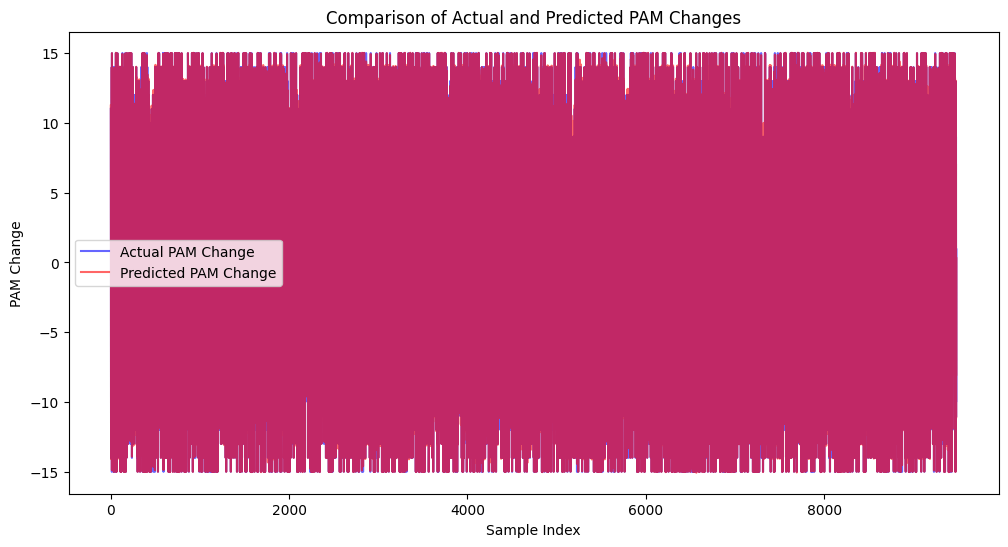

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual PAM Change", color="blue", alpha=0.6)
plt.plot(y_pred, label="Predicted PAM Change", color="red", alpha=0.6)
plt.legend()
plt.title("Comparison of Actual and Predicted PAM Changes")
plt.xlabel("Sample Index")
plt.ylabel("PAM Change")
plt.show()
